In [4]:
!pip install snowflake-connector-python snowflake-sqlalchemy dotenv


[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [27]:
import pandas as pd
import os
from dotenv import load_dotenv
import snowflake.connector
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv("snowflake.env")

conn = snowflake.connector.connect(
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    user=os.getenv("SNOWFLAKE_USER"),
    password=os.getenv("SNOWFLAKE_PASSWORD"),
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA"),
)

df = pd.read_sql("SELECT * FROM HEART_RAW;", conn)
df.head()

C:\Users\emanu\AppData\Local\Temp\ipykernel_11692\2204678549.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM HEART_RAW;", conn)


,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Step 1 — Análise estatística descritiva
Neste passo realizamos a etapa de Understanding the Dataset, tal como descrito no artigo. Calculamos estatísticas descritivas (média, mediana, desvio padrão, valores mínimo e máximo) para as variáveis numéricas e analisamos a distribuição das variáveis categóricas. Essa visão inicial serve para entender o perfil da base e apoiar as decisões de limpeza, principalmente em atributos clínicos sensíveis como pressão arterial, colesterol e medidas relacionadas ao esforço.

In [21]:
NUMERIC_COLS = ['AGE', 'TRESTBPS', 'CHOL', 'THALACH', 'OLDPEAK']
CATEGORICAL_COLS = ['SEX', 'CP', 'FBS', 'RESTECG', 'EXANG', 'SLOPE', 'CA', 'THAL']

print("ESTATÍSTICAS DAS COLUNAS NUMÉRICAS:")
display(df[NUMERIC_COLS].describe())

print("\nDISTRIBUIÇÃO DAS COLUNAS CATEGÓRICAS:")
for COL in CATEGORICAL_COLS:
    print(f"\n{COL}:")
    print(df[COL].value_counts())





ESTATÍSTICAS DAS COLUNAS NUMÉRICAS:


,AGE,TRESTBPS,CHOL,THALACH,OLDPEAK
count,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000
mean,54.434146,131.611707,246.00000,149.114146,1.071512
std,9.072290,17.516718,51.59251,23.005724,1.175053
min,29.000000,94.000000,126.00000,71.000000,0.000000
25%,48.000000,120.000000,211.00000,132.000000,0.000000
50%,56.000000,130.000000,240.00000,152.000000,0.800000
75%,61.000000,140.000000,275.00000,166.000000,1.800000
max,77.000000,200.000000,564.00000,202.000000,6.200000



DISTRIBUIÇÃO DAS COLUNAS CATEGÓRICAS:

SEX:
SEX
1    713
0    312
Name: count, dtype: int64

CP:
CP
0    497
2    284
1    167
3     77
Name: count, dtype: int64

FBS:
FBS
0    872
1    153
Name: count, dtype: int64

RESTECG:
RESTECG
1    513
0    497
2     15
Name: count, dtype: int64

EXANG:
EXANG
0    680
1    345
Name: count, dtype: int64

SLOPE:
SLOPE
1    482
2    469
0     74
Name: count, dtype: int64

CA:
CA
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64

THAL:
THAL
2    544
3    410
1     64
0      7
Name: count, dtype: int64


Step 2 — Identificação visual de outliers
O artigo dá atenção especial a outliers em pressão arterial em repouso (RestingBP), colesterol sérico (Cholesterol) e depressão do segmento ST (Oldpeak). Para seguir a mesma abordagem, utilizamos gráficos de dispersão (stripplots) para visualizar a distribuição desses atributos em relação à variável alvo (target). Essa inspeção auxilia na definição de limites clínicos razoáveis para a etapa de limpeza.

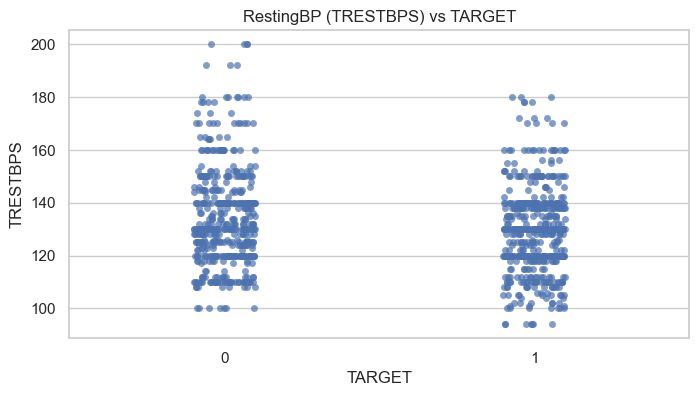

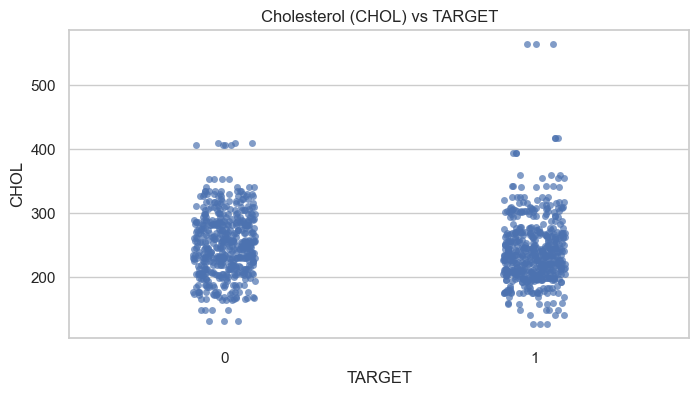

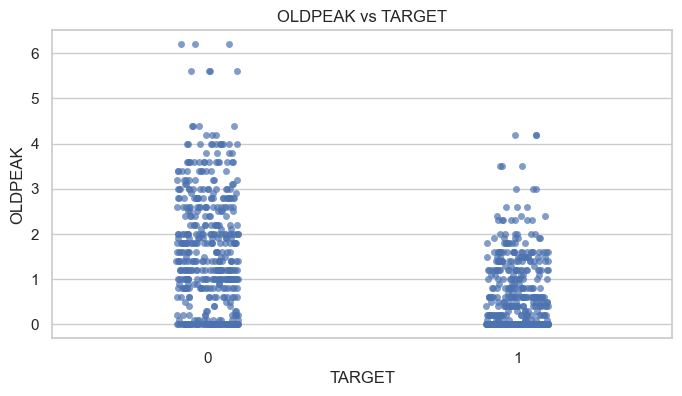

In [29]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(8,4))
sns.stripplot(data=df, x="TARGET", y="TRESTBPS", jitter=True, alpha=0.7)
plt.title("RestingBP (TRESTBPS) vs TARGET")
plt.show()

plt.figure(figsize=(8,4))
sns.stripplot(data=df, x="TARGET", y="CHOL", jitter=True, alpha=0.7)
plt.title("Cholesterol (CHOL) vs TARGET")
plt.show()

plt.figure(figsize=(8,4))
sns.stripplot(data=df, x="TARGET", y="OLDPEAK", jitter=True, alpha=0.7)
plt.title("OLDPEAK vs TARGET")
plt.show()



In [ ]:
Step 3 — Limpeza dos dados (data cleaning)
Nesta etapa aplicamos as regras de limpeza inspiradas diretamente na metodologia do artigo. Os autores tratam valores clinicamente impossíveis ou improváveis, em especial:

Pressão arterial em repouso (RestingBP) muito baixa, removendo valores abaixo de um limite mínimo.

Valores extremos de colesterol, removendo observações com colesterol muito baixo ou muito alto.

Substituição de colesterol igual a zero pela mediana, pois esse valor não é plausível clinicamente.

Remoção de valores negativos de oldpeak.
Além disso, removemos linhas duplicadas e verificamos a presença de valores ausentes. Essa etapa é crucial para garantir que o modelo aprenda a partir de dados consistentes, reduzindo o risco de distorções nas métricas.

In [31]:
# REMOÇÃO DE DUPLICATAS
df = df.drop_duplicates()

# CHECAGEM DE NULOS
print("NULOS POR COLUNA ANTES DA LIMPEZA:")
print(df.isna().sum())

# REMOÇÃO/APROXIMAÇÃO DE VALORES INVÁLIDOS, SEGUINDO O ESPÍRITO DO ARTIGO

# 1) TRESTBPS: REMOVER VALORES MUITO BAIXOS (< 80)
df = df[df['TRESTBPS'] >= 80]

# 2) CHOL: MANTER EM INTERVALO CLÍNICO PLAUSÍVEL (100 A 450)
df = df[(df['CHOL'] >= 100) & (df['CHOL'] <= 450)]

# 3) OLDPEAK: REMOVER VALORES NEGATIVOS
df = df[df['OLDPEAK'] >= 0]

# 4) SUBSTITUIR CHOL = 0 PELA MEDIANA
CHOL_MEDIANA = df['CHOL'].median()
df['CHOL'] = df['CHOL'].replace(0, CHOL_MEDIANA)

print("\nESTATÍSTICAS APÓS LIMPEZA:")
display(df[NUMERIC_COLS].describe())

print("\nNULOS POR COLUNA APÓS LIMPEZA:")
print(df.isna().sum())


NULOS POR COLUNA ANTES DA LIMPEZA:
AGE         0
SEX         0
CP          0
TRESTBPS    0
CHOL        0
FBS         0
RESTECG     0
THALACH     0
EXANG       0
OLDPEAK     0
SLOPE       0
CA          0
THAL        0
TARGET      0
dtype: int64

ESTATÍSTICAS APÓS LIMPEZA:


,AGE,TRESTBPS,CHOL,THALACH,OLDPEAK
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,54.378738,131.657807,245.445183,149.534884,1.041196
std,9.033793,17.566422,48.479011,22.933737,1.162940
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.000000,0.000000
50%,55.000000,130.000000,240.000000,152.000000,0.800000
75%,61.000000,140.000000,274.000000,166.000000,1.600000
max,77.000000,200.000000,417.000000,202.000000,6.200000



NULOS POR COLUNA APÓS LIMPEZA:
AGE         0
SEX         0
CP          0
TRESTBPS    0
CHOL        0
FBS         0
RESTECG     0
THALACH     0
EXANG       0
OLDPEAK     0
SLOPE       0
CA          0
THAL        0
TARGET      0
dtype: int64


Step 4 — Codificação das variáveis categóricas
Assim como no artigo, realizamos a transformação das variáveis categóricas para valores numéricos por meio de Label Encoding. No nosso caso, muitas colunas já estão representadas por inteiros (por exemplo, cp, thal, restecg), mas aplicamos o encoder de forma sistemática para manter consistência com o fluxo de pré-processamento descrito pelos autores e evitar possíveis diferenças de codificação entre ambientes.

In [36]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder()

for COL in CATEGORICAL_COLS:
    df[COL] = LE.fit_transform(df[COL])

df.head()



,AGE,SEX,CP,TRESTBPS,CHOL,FBS,RESTECG,THALACH,EXANG,OLDPEAK,SLOPE,CA,THAL,TARGET
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Step 5 — Separação entre X e y
Aqui separamos as variáveis de entrada (X) da variável alvo (Y = TARGET), preparando o dataset para as etapas de normalização, divisão treino/teste e modelagem.

In [37]:
X = df.drop("TARGET", axis=1)
Y = df["TARGET"]

print("FORMATO DE X:", X.shape)
print("FORMATO DE Y:", Y.shape)


FORMATO DE X: (301, 13)
FORMATO DE Y: (301,)


Step 6 — Divisão treino/teste e normalização
Conforme o artigo, dividimos os dados em treino (70%) e teste (30%), usando estratificação para manter a proporção de classes. Em seguida, aplicamos StandardScaler para padronizar as features, o que é essencial para o KNN e outros modelos baseados em distância.

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_TRAIN, X_TEST, Y_TRAIN, Y_TEST = train_test_split(
    X,
    Y,
    test_size=0.3,
    random_state=42,
    stratify=Y
)

SCALER = StandardScaler()
X_TRAIN_SCALED = SCALER.fit_transform(X_TRAIN)
X_TEST_SCALED = SCALER.transform(X_TEST)

print("SHAPE TREINO:", X_TRAIN_SCALED.shape)
print("SHAPE TESTE:", X_TEST_SCALED.shape)


SHAPE TREINO: (210, 13)
SHAPE TESTE: (91, 13)


Step 7 — Treinamento dos modelos base
Nesta etapa treinamos vários classificadores clássicos (Regressão Logística, Árvore de Decisão, Random Forest, SVM, Naive Bayes e KNN padrão) para obter um baseline de desempenho. Essa comparação é importante para justificar a escolha do KNN como modelo a ser otimizado, assim como feito no artigo.Step 7 — Treinamento dos modelos base
Nesta etapa treinamos vários classificadores clássicos (Regressão Logística, Árvore de Decisão, Random Forest, SVM, Naive Bayes e KNN padrão) para obter um baseline de desempenho. Essa comparação é importante para justificar a escolha do KNN como modelo a ser otimizado, assim como feito no artigo.

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

MODELS = {
    "LOGISTIC_REGRESSION": LogisticRegression(max_iter=1000),
    "DECISION_TREE": DecisionTreeClassifier(random_state=42),
    "RANDOM_FOREST": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "NAIVE_BAYES": GaussianNB(),
    "KNN_DEFAULT": KNeighborsClassifier()
}

BASELINE_RESULTS = []

for NAME, MODEL in MODELS.items():
    MODEL.fit(X_TRAIN_SCALED, Y_TRAIN)
    Y_PRED = MODEL.predict(X_TEST_SCALED)

    ACC = accuracy_score(Y_TEST, Y_PRED)
    PREC = precision_score(Y_TEST, Y_PRED)
    REC = recall_score(Y_TEST, Y_PRED)
    F1 = f1_score(Y_TEST, Y_PRED)

    BASELINE_RESULTS.append({
        "MODELO": NAME,
        "ACCURACY": ACC,
        "PRECISION": PREC,
        "RECALL": REC,
        "F1": F1
    })

    print(f"=== {NAME} ===")
    print("ACCURACY:", ACC)
    print("PRECISION:", PREC)
    print("RECALL:", REC)
    print("F1:", F1)
    print()

pd.DataFrame(BASELINE_RESULTS)


=== LOGISTIC_REGRESSION ===
ACCURACY: 0.8131868131868132
PRECISION: 0.82
RECALL: 0.8367346938775511
F1: 0.8282828282828283

=== DECISION_TREE ===
ACCURACY: 0.7582417582417582
PRECISION: 0.813953488372093
RECALL: 0.7142857142857143
F1: 0.7608695652173914

=== RANDOM_FOREST ===
ACCURACY: 0.7912087912087912
PRECISION: 0.8125
RECALL: 0.7959183673469388
F1: 0.8041237113402062

=== SVM ===
ACCURACY: 0.7692307692307693
PRECISION: 0.78
RECALL: 0.7959183673469388
F1: 0.7878787878787878

=== NAIVE_BAYES ===
ACCURACY: 0.8351648351648352
PRECISION: 0.8541666666666666
RECALL: 0.8367346938775511
F1: 0.845360824742268

=== KNN_DEFAULT ===
ACCURACY: 0.7912087912087912
PRECISION: 0.7884615384615384
RECALL: 0.8367346938775511
F1: 0.8118811881188119



,MODELO,ACCURACY,PRECISION,RECALL,F1
0,LOGISTIC_REGRESSION,0.813187,0.820000,0.836735,0.828283
1,DECISION_TREE,0.758242,0.813953,0.714286,0.760870
2,RANDOM_FOREST,0.791209,0.812500,0.795918,0.804124
3,SVM,0.769231,0.780000,0.795918,0.787879
4,NAIVE_BAYES,0.835165,0.854167,0.836735,0.845361
5,KNN_DEFAULT,0.791209,0.788462,0.836735,0.811881


Step 8 — Otimização do KNN com GridSearchCV
Agora seguimos o artigo e aplicamos um Grid Search para encontrar a melhor combinação de hiperparâmetros do KNN, variando número de vizinhos, métrica de distância e tipo de ponderação. Usamos validação cruzada de 5 folds para estimar o desempenho médio de cada configuração.

In [40]:
from sklearn.model_selection import GridSearchCV

PARAM_GRID = {
    "n_neighbors": [3, 5, 7, 9, 11, 15, 21],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "weights": ["uniform", "distance"]
}

GRID = GridSearchCV(
    KNeighborsClassifier(),
    PARAM_GRID,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

GRID.fit(X_TRAIN_SCALED, Y_TRAIN)

BEST_KNN = GRID.best_estimator_
print("MELHORES PARÂMETROS:", GRID.best_params_)
print("MELHOR SCORE (CV):", GRID.best_score_)


MELHORES PARÂMETROS: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'distance'}
MELHOR SCORE (CV): 0.8476190476190476


Step 9 — Avaliação do KNN otimizado
Por fim, avaliamos o KNN otimizado no conjunto de teste, calculando acurácia, precisão, recall, F1-score, matriz de confusão e curva ROC/AUC, reproduzindo o tipo de análise apresentada no artigo.

=== KNN TUNADO ===
ACCURACY: 0.8131868131868132
PRECISION: 0.7962962962962963
RECALL: 0.8775510204081632
F1: 0.8349514563106796

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

           0       0.84      0.74      0.78        42
           1       0.80      0.88      0.83        49

    accuracy                           0.81        91
   macro avg       0.82      0.81      0.81        91
weighted avg       0.82      0.81      0.81        91



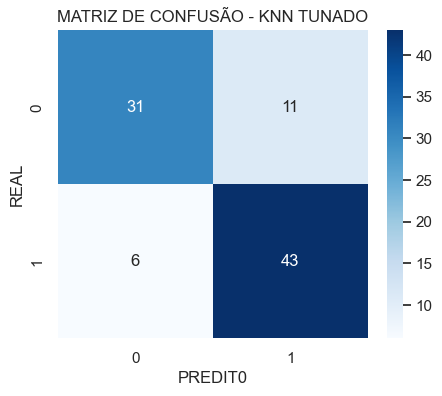

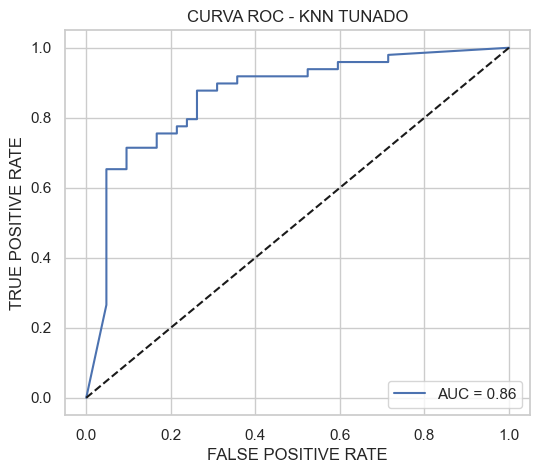

AUC: 0.8634596695821186


In [41]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report

Y_PRED_KNN = BEST_KNN.predict(X_TEST_SCALED)
Y_PROBA_KNN = BEST_KNN.predict_proba(X_TEST_SCALED)[:, 1]

ACC = accuracy_score(Y_TEST, Y_PRED_KNN)
PREC = precision_score(Y_TEST, Y_PRED_KNN)
REC = recall_score(Y_TEST, Y_PRED_KNN)
F1 = f1_score(Y_TEST, Y_PRED_KNN)

print("=== KNN TUNADO ===")
print("ACCURACY:", ACC)
print("PRECISION:", PREC)
print("RECALL:", REC)
print("F1:", F1)
print("\nCLASSIFICATION REPORT:\n", classification_report(Y_TEST, Y_PRED_KNN))

# MATRIZ DE CONFUSÃO
plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(Y_TEST, Y_PRED_KNN), annot=True, fmt="d", cmap="Blues")
plt.xlabel("PREDIT0")
plt.ylabel("REAL")
plt.title("MATRIZ DE CONFUSÃO - KNN TUNADO")
plt.show()

# CURVA ROC
FPR, TPR, _ = roc_curve(Y_TEST, Y_PROBA_KNN)
ROC_AUC = auc(FPR, TPR)

plt.figure(figsize=(6, 5))
plt.plot(FPR, TPR, label=f"AUC = {ROC_AUC:.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("FALSE POSITIVE RATE")
plt.ylabel("TRUE POSITIVE RATE")
plt.title("CURVA ROC - KNN TUNADO")
plt.legend(loc="lower right")
plt.show()

print("AUC:", ROC_AUC)


Histograma + KDE de AGE

Visualização 1 — Distribuição da idade (AGE)
Nesta visualização analisamos a distribuição da idade dos pacientes. O objetivo é identificar faixas etárias mais frequentes e reforçar a relação entre idade avançada e maior risco de doença cardíaca, como discutido no artigo. Essa análise ajuda a contextualizar o perfil da população estudada e mostra que a maioria dos casos se concentra em pacientes de meia-idade e idosos.

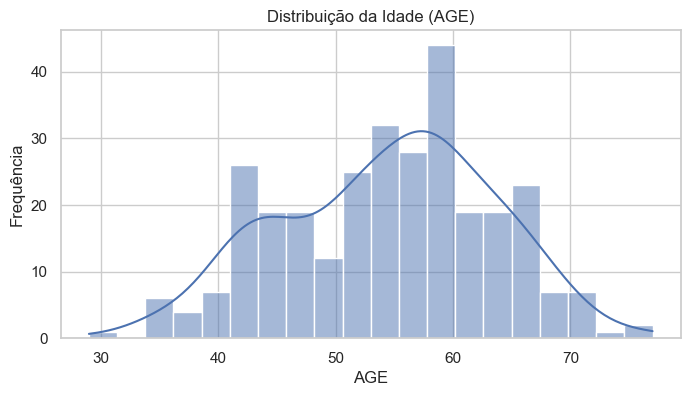

In [43]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="AGE", kde=True, bins=20)
plt.title("Distribuição da Idade (AGE)")
plt.xlabel("AGE")
plt.ylabel("Frequência")
plt.show()


Histograma + KDE de TRESTBPS

Visualização 2 — Distribuição da pressão arterial em repouso (TRESTBPS)
Aqui avaliamos a distribuição da pressão arterial em repouso. Esse gráfico é importante para justificar a remoção de outliers de TRESTBPS, como feito no artigo. Valores muito baixos ou muito altos podem indicar registros incorretos ou casos extremos que distorcem o treinamento do modelo, por isso a análise visual antecede as regras de limpeza.

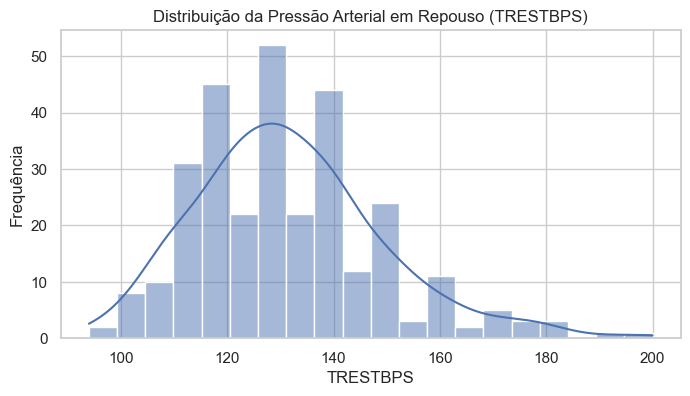

In [44]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x="TRESTBPS", kde=True, bins=20)
plt.title("Distribuição da Pressão Arterial em Repouso (TRESTBPS)")
plt.xlabel("TRESTBPS")
plt.ylabel("Frequência")
plt.show()


Scatterplot AGE × CHOL

Visualização 3 — Relação entre idade (AGE) e colesterol (CHOL)
Nesta figura observamos a relação entre idade e colesterol, destacando visualmente como esses dois fatores se combinam no risco cardiovascular. Pacientes mais velhos com níveis elevados de colesterol tendem a estar em maior risco, e o gráfico ajuda a enxergar possíveis padrões. A cor por TARGET evidencia como os casos com doença cardíaca se distribuem nesse espaço.

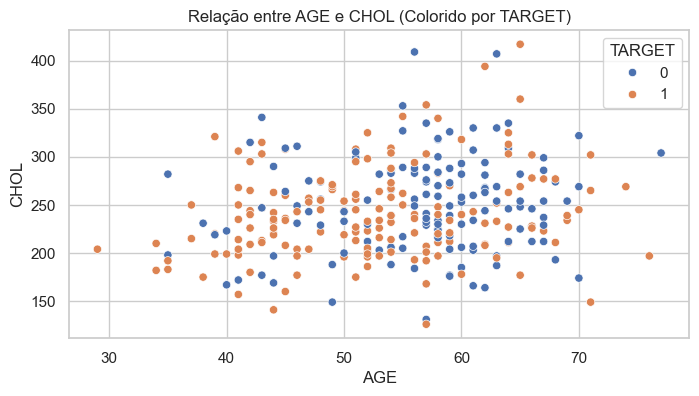

In [45]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=df, x="AGE", y="CHOL", hue="TARGET")
plt.title("Relação entre AGE e CHOL (Colorido por TARGET)")
plt.xlabel("AGE")
plt.ylabel("CHOL")
plt.legend(title="TARGET")
plt.show()


Barplot de CP (Chest Pain Type)

Visualização 4 — Distribuição dos tipos de dor no peito (CP)
Aqui analisamos a frequência dos diferentes tipos de dor no peito (CP). O artigo destaca que certos tipos de dor, como angina típica e atípica, são mais frequentes entre pacientes cardíacos. Este gráfico ajuda a entender quais categorias de CP predominam no conjunto de dados e serve de base para discutir a importância clínica desse atributo na predição.

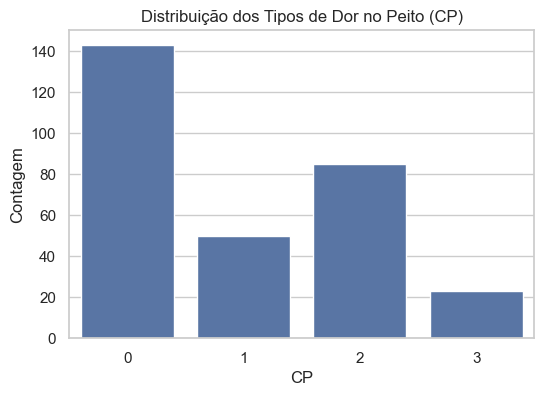

In [46]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="CP")
plt.title("Distribuição dos Tipos de Dor no Peito (CP)")
plt.xlabel("CP")
plt.ylabel("Contagem")
plt.show()
